# SCANIA Truck Component RUL Prediction Pipeline

5-section end-to-end pipeline:
1. **Data Cleaning** — filter high-missing / constant / duplicate columns
2. **Temporal Aggregation + Labels** — rolling mean features, ordinal RUL labels (0–4), Spec columns
3. **RFOD Anomaly Scores** — Random Forest Outlier Detection with multi-threshold retraining
4. **XGBoost Classification** — 5-class classifier with sample weighting
5. **Cost Matrix Evaluation** — 4 strategies compared on 5×5 asymmetric cost matrix; test set submission

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_fscore_support, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold, RandomizedSearchCV, StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from scipy.stats import randint, uniform

PROJECT_DIR = Path(".").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from scania_feature_engineering import (
    clean_split,
    patch_missing_inplace,
    build_features,
    rul_to_ordinal,
)
from scania_xgb_common import (
    COST,
    total_cost,
    build_model_pipeline,
    ordinal_risk_score,
    predict_with_threshold_vector,
    tune_threshold_vector,
    compute_sample_weights,
    write_scania_submission_csv,
    repaired_vehicle_ids,
)

RANDOM_STATE = 42
print("Imports OK")

Imports OK


In [2]:
SCANIA_DIR  = PROJECT_DIR / "Datasets" / "SCANIA" / "SCANIA"
WINDOW_SIZE = 10
SAMPLE_FRAC = 0.3   # fraction of normal samples used in RFOD train set
N_CLASSES   = 5

print(f"SCANIA_DIR : {SCANIA_DIR}  exists={SCANIA_DIR.exists()}")
print(f"Window size: {WINDOW_SIZE}  |  RFOD sample frac: {SAMPLE_FRAC}")

SCANIA_DIR : /home/ruiyao/cs_5344/Project/Datasets/SCANIA/SCANIA  exists=True
Window size: 10  |  RFOD sample frac: 0.3


---
## 1. Data Cleaning

Filter high-missing (>80%), constant, and duplicate columns. Fit on train, then apply the same column mask to validation and test. Patch remaining NaN with per-column train medians.

In [3]:
print("Loading raw operational readout CSVs...")
train_ops = pd.read_csv(SCANIA_DIR / "train_operational_readouts.csv")
val_ops   = pd.read_csv(SCANIA_DIR / "validation_operational_readouts.csv")
test_ops  = pd.read_csv(SCANIA_DIR / "test_operational_readouts.csv")
print(f"Train ops : {train_ops.shape}  ({train_ops['vehicle_id'].nunique():,} vehicles)")
print(f"Val ops   : {val_ops.shape}  ({val_ops['vehicle_id'].nunique():,} vehicles)")
print(f"Test ops  : {test_ops.shape}  ({test_ops['vehicle_id'].nunique():,} vehicles)")

Loading raw operational readout CSVs...


Train ops : (1122452, 107)  (23,550 vehicles)
Val ops   : (119103, 107)  (3,027 vehicles)
Test ops  : (275264, 107)  (7,064 vehicles)


In [4]:
print("\nCleaning (fit on train, apply to all)...")
train_ops_clean, val_ops_clean, test_ops_clean = clean_split(
    train_ops, val_ops, test_ops,
    exclude_cols=["vehicle_id", "time_step"],
)

sensor_cols = [c for c in train_ops_clean.columns if c not in ("vehicle_id", "time_step")]
fill_values = {col: train_ops_clean[col].median() for col in sensor_cols}

print("Patching missing values with train medians...")
for name, df in [("Train", train_ops_clean), ("Val", val_ops_clean), ("Test", test_ops_clean)]:
    before = df[sensor_cols].isna().sum().sum()
    patch_missing_inplace([df], sensor_cols, fill_values)
    after = df[sensor_cols].isna().sum().sum()
    print(f"  {name:5s}: {before:>10,} NaN  ->  {after:>10,} NaN")

print(f"\nTrain clean: {train_ops_clean.shape}")
print(f"Val clean  : {val_ops_clean.shape}")
print(f"Test clean : {test_ops_clean.shape}")
print(f"Sensor cols: {len(sensor_cols)}")


Cleaning (fit on train, apply to all)...


  Result: 107 cols → 107 cols



Patching missing values with train medians...


  Train:    354,634 NaN  ->           0 NaN
  Val  :     37,179 NaN  ->           0 NaN


  Test :     89,563 NaN  ->           0 NaN

Train clean: (1122452, 107)
Val clean  : (119103, 107)
Test clean : (275264, 107)
Sensor cols: 105


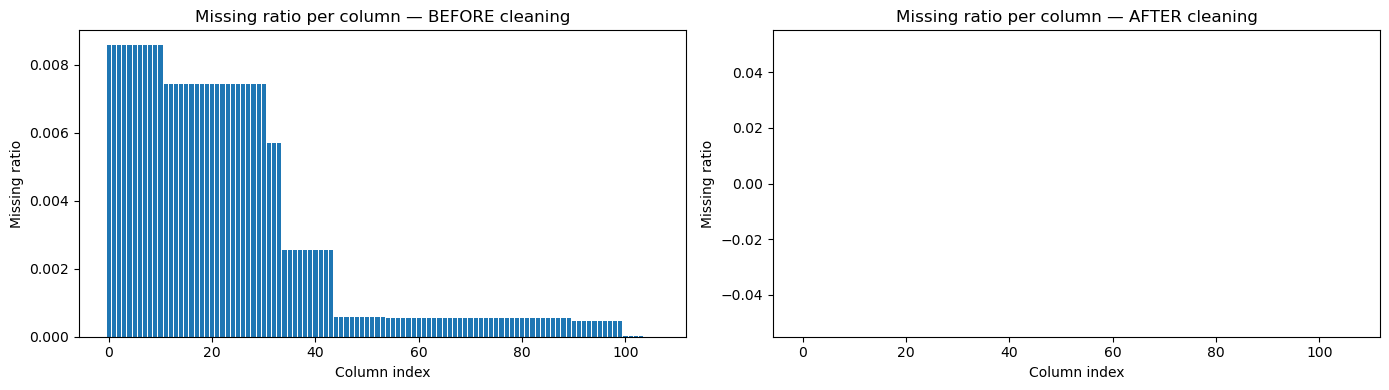

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_before = train_ops.isna().mean().sort_values(ascending=False)
miss_after  = train_ops_clean.isna().mean().sort_values(ascending=False)
axes[0].bar(range(len(miss_before)), miss_before.values)
axes[0].set_title("Missing ratio per column — BEFORE cleaning")
axes[0].set_xlabel("Column index"); axes[0].set_ylabel("Missing ratio")
axes[1].bar(range(len(miss_after)), miss_after.values, color="steelblue")
axes[1].set_title("Missing ratio per column — AFTER cleaning")
axes[1].set_xlabel("Column index"); axes[1].set_ylabel("Missing ratio")
plt.tight_layout(); plt.show()

---
## 2. Temporal Aggregation + Label Generation

- **Temporal aggregation**: rolling mean over last `WINDOW_SIZE` time steps per vehicle
- **Training labels**: per-row ordinal RUL (0=safe, 4=critical) from `train_tte.csv`; non-repaired vehicles get label=0
- **Validation labels**: last time step per vehicle, merged from `validation_labels.csv`
- **Specification columns**: `Spec_0~Spec_7` merged as raw categorical (mode-filled)

In [6]:
print(f"Building temporal features (window={WINDOW_SIZE})...")

t0 = time.time()
train_feat = build_features(train_ops_clean, sensor_cols, WINDOW_SIZE)
print(f"  Train : {train_feat.shape}  ({time.time()-t0:.1f}s)")

t0 = time.time()
val_feat = build_features(val_ops_clean, sensor_cols, WINDOW_SIZE)
print(f"  Val   : {val_feat.shape}  ({time.time()-t0:.1f}s)")

t0 = time.time()
test_feat = build_features(test_ops_clean, sensor_cols, WINDOW_SIZE)
print(f"  Test  : {test_feat.shape}  ({time.time()-t0:.1f}s)")

Building temporal features (window=10)...


  Train : (1122452, 107)  (55.0s)


  Val   : (119103, 107)  (8.3s)


  Test  : (275264, 107)  (19.3s)


In [7]:
# ── Training labels: per-row RUL from train_tte ──────────────────────────────
train_tte = pd.read_csv(SCANIA_DIR / "train_tte.csv")
train_feat = train_feat.merge(
    train_tte[["vehicle_id", "length_of_study_time_step", "in_study_repair"]],
    on="vehicle_id", how="left",
)
rep   = pd.to_numeric(train_feat["in_study_repair"], errors="coerce").fillna(0).astype(int).to_numpy()
T     = train_feat["length_of_study_time_step"].to_numpy()
t_cur = train_feat["time_step"].to_numpy()
rul   = np.where(rep == 1, np.maximum(T - t_cur, 0.0), np.inf)
train_feat["label"] = np.where(np.isfinite(rul), rul_to_ordinal(rul), 0)
train_feat.drop(columns=["length_of_study_time_step", "in_study_repair"], inplace=True)

# ── Validation: last time step per vehicle + official labels ─────────────────
val_feat = val_feat.groupby("vehicle_id").tail(1).reset_index(drop=True)
val_labels = pd.read_csv(SCANIA_DIR / "validation_labels.csv")
val_feat = val_feat.merge(
    val_labels.rename(columns={"class_label": "label"})[["vehicle_id", "label"]],
    on="vehicle_id", how="left",
)

# ── Test: last time step per vehicle (no labels) ─────────────────────────────
test_feat = test_feat.groupby("vehicle_id").tail(1).reset_index(drop=True)

# ── Specification columns (raw categorical, mode-filled) ─────────────────────
train_specs = pd.read_csv(SCANIA_DIR / "train_specifications.csv")
val_specs   = pd.read_csv(SCANIA_DIR / "validation_specifications.csv")
test_specs  = pd.read_csv(SCANIA_DIR / "test_specifications.csv")
spec_cols   = sorted(c for c in train_specs.columns if c.startswith("Spec_"))
cat_fill    = {col: train_specs[col].mode()[0] for col in spec_cols}
for df in [train_specs, val_specs, test_specs]:
    for col in spec_cols:
        df[col] = df[col].fillna(cat_fill[col])

train_feat = train_feat.merge(train_specs[["vehicle_id"] + spec_cols], on="vehicle_id", how="left")
val_feat   = val_feat.merge(val_specs[["vehicle_id"] + spec_cols],     on="vehicle_id", how="left")
test_feat  = test_feat.merge(test_specs[["vehicle_id"] + spec_cols],   on="vehicle_id", how="left")

print(f"Train feat: {train_feat.shape}")
print(f"Val feat  : {val_feat.shape}")
print(f"Test feat : {test_feat.shape}")
print("\nTrain label distribution:")
for lbl, cnt in train_feat["label"].value_counts().sort_index().items():
    print(f"  class {lbl}: {cnt:>8,}  ({100*cnt/len(train_feat):.1f}%)")
print("\nVal label distribution:")
for lbl, cnt in val_feat["label"].value_counts().sort_index().items():
    print(f"  class {lbl}: {cnt:>8,}  ({100*cnt/len(val_feat):.1f}%)")

Train feat: (1122452, 116)
Val feat  : (3027, 116)
Test feat : (7064, 115)

Train label distribution:
  class 0: 1,096,712  (97.7%)
  class 1:   12,503  (1.1%)
  class 2:    6,179  (0.6%)
  class 3:    3,200  (0.3%)
  class 4:    3,858  (0.3%)

Val label distribution:
  class 0:    2,944  (97.3%)
  class 1:       12  (0.4%)
  class 2:        9  (0.3%)
  class 3:       21  (0.7%)
  class 4:       41  (1.4%)


---
## 3. RFOD Anomaly Scores

RFOD (Random Forest Outlier Detection) trains one random forest per feature to predict
that feature from all others. Anomaly score = weighted Gower distance between
prediction and true value across all features.

Multiple thresholds `k` are used: for each `k ∈ {0,1,2,3}`, RFOD is retrained treating
labels `0..k` as normal and `> k` as anomaly, producing `anomaly_score_k` columns.

### 3.1 RFOD Helper Functions

In [8]:
RFOD_ALPHA = [0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.25]


def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-5))


def alphaquantile(matrix1, matrix2, categorical_columns, continuous_columns,
                  column_names, model_scores, residual, weighted=True):
    """Compute improved Gower distance for multiple alpha thresholds."""
    n_rows, n_cols = matrix1.shape
    result = {}
    for a in RFOD_ALPHA:
        diff_matrix = np.zeros((n_rows, n_cols))
        for col in continuous_columns:
            col_name = column_names[col]
            iqr = np.percentile(residual[col_name], 100 * (1 - a)) * 2
            if iqr == 0:
                scaled_diff = np.zeros_like(matrix1[:, col])
            else:
                scaled_diff = np.clip(np.abs(matrix1[:, col] - matrix2[:, col]) / iqr, 0, 1)
            diff_matrix[:, col] = scaled_diff
        for col_idx in categorical_columns:
            diff_matrix[:, col_idx] = 1 - matrix1[:, col_idx]  # false proba
        if weighted:
            mean_diff = np.sum(diff_matrix * np.array(model_scores), axis=1)
        else:
            mean_diff = np.mean(diff_matrix, axis=1)
        result[a] = (diff_matrix, mean_diff)
    return result


def calc_resi(col_name, Xy, treeid, model):
    X_resi = Xy.drop(columns=[col_name])
    y_resi = Xy[col_name]
    preds = sum(model.estimators_[idx].predict(X_resi.values) for idx in treeid)
    return np.abs(preds / len(treeid) - y_resi.values)


print("RFOD helper functions defined.")

RFOD helper functions defined.


In [9]:
_rfod_col_name = None  # will be set in the training loop


def _tree_scoring(tree, X, y, col_name, num_cols):
    if col_name in num_cols:
        y_pred = tree.predict(X)
        return smape(y, y_pred), y_pred
    else:
        y_pred = tree.predict_proba(X)
        n_cls = y_pred.shape[1]
        if n_cls != len(np.unique(y)) or n_cls <= 1:
            score = 0
        elif n_cls == 2:
            score = roc_auc_score(y, y_pred[:, 1])
        else:
            score = roc_auc_score(y, y_pred, multi_class="ovr")
        return 1 - score, y_pred


def _trees_scoring(y_preds, y, col_name, num_cols):
    y_preds = np.mean(y_preds, axis=0)
    if col_name in num_cols:
        return smape(y, y_preds)
    else:
        n_cls = y_preds.shape[1]
        if n_cls != len(np.unique(y)) or n_cls <= 1:
            return 1.0
        elif n_cls == 2:
            return 1 - roc_auc_score(y, y_preds[:, 1])
        else:
            return 1 - roc_auc_score(y, y_preds, multi_class="ovr")


def train_rf_feature(col_name, num_cols, categ_cols,
                     X_processed_train, X_processed_valid,
                     X_train, X_valid, process_list):
    """Train one RF per feature and select best tree subset via golden-section search."""
    rf_X_train = X_processed_train.drop(columns=process_list[col_name])
    rf_X_valid = X_processed_valid.drop(columns=process_list[col_name])
    rf_y_train = X_train[col_name]
    rf_y_valid = X_valid[col_name]

    if col_name in num_cols:
        rf_model = RandomForestRegressor(n_estimators=50, n_jobs=-1)
    else:
        rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    t0 = time.time()
    rf_model.fit(rf_X_train.values, rf_y_train)
    tr_time = time.time() - t0

    trees = rf_model.estimators_
    t0 = time.time()
    output_trees = Parallel(n_jobs=-1)(
        delayed(_tree_scoring)(tree, rf_X_valid.values, rf_y_valid.values, col_name, num_cols)
        for tree in trees
    )
    errors, preds = zip(*output_trees)
    tree_oob_errors = np.asarray(errors, float)
    y_preds = np.stack(preds, axis=0)
    tree_indices = np.argsort(tree_oob_errors)
    sorted_errors = tree_oob_errors[tree_indices]

    # Golden-section search for best tree count
    trees_oob_errors = {}
    lef, rig = 0, 399
    while lef + 3 <= rig:
        midl = int(rig - (rig - lef) * 0.61803398875)
        midr = int(lef + (rig - lef) * 0.61803398875)
        for mid in (midl, midr):
            if mid not in trees_oob_errors:
                trees_oob_errors[mid] = (
                    _trees_scoring(y_preds[tree_indices[:mid + 1]], rf_y_valid.values, col_name, num_cols)
                    + sorted_errors[0] * 0.3 / np.sqrt((mid + 1) / 10)
                )
        if trees_oob_errors[midl] < trees_oob_errors[midr]:
            rig = midr
        else:
            lef = midl

    Best_trees = 5
    trees_oob_errors.setdefault(
        Best_trees,
        _trees_scoring(y_preds[tree_indices[:Best_trees + 1]], rf_y_valid.values, col_name, num_cols)
        + sorted_errors[0] * 0.3 / np.sqrt((Best_trees + 1) / 10)
    )
    for i in range(lef, rig + 1):
        trees_oob_errors.setdefault(
            i,
            _trees_scoring(y_preds[tree_indices[:i + 1]], rf_y_valid.values, col_name, num_cols)
            + sorted_errors[0] * 0.3 / np.sqrt((i + 1) / 10)
        )
        if trees_oob_errors[i] < trees_oob_errors[Best_trees]:
            Best_trees = i

    pr_time = time.time() - t0
    return {
        "tree_indices": tree_indices,
        "rf_model": rf_model,
        "tr_time": tr_time,
        "pr_time": pr_time,
        "tree_used": max(Best_trees, 5),
        "feature_performance": float(np.mean(sorted_errors[:max(1, Best_trees - 1)])),
    }


def predict_feature(col_name, tree_used, true_value, tree_indices, rf_model, num_cols,
                    X_processed_test, process_list):
    """Predict one feature from all others; return confidence scores and predictions."""
    top_idx = tree_indices[:tree_used]
    trees   = rf_model.estimators_
    predict_X = X_processed_test.drop(columns=process_list[col_name]).to_numpy()

    if col_name in num_cols:
        top_preds = np.array([trees[i].predict(predict_X) for i in top_idx])
        final_pred = top_preds.mean(axis=0)
        confidence_scores = np.std(top_preds, axis=0, ddof=1)
    else:
        class_idx_map = {label: i for i, label in enumerate(rf_model.classes_)}
        map_func = np.vectorize(lambda x: class_idx_map.get(x, -1))
        true_cls = map_func(true_value)
        valid = true_cls != -1
        true_proba = np.zeros((predict_X.shape[0], len(top_idx)))
        for j, idx in enumerate(top_idx):
            tp = trees[idx].predict_proba(predict_X)
            tt = np.zeros(predict_X.shape[0])
            tt[valid] = tp[np.arange(predict_X.shape[0])[valid], true_cls[valid]]
            true_proba[:, j] = tt
        final_pred = true_proba.mean(axis=1)
        confidence_scores = np.std(true_proba, axis=1, ddof=1)

    return {"confidence_scores": confidence_scores, "final_pred": final_pred}


print("RFOD core functions defined.")

RFOD core functions defined.


### 3.2 Data Preparation for RFOD

In [10]:
_meta_cols = {"vehicle_id", "time_step", "label"}
_feat_cols = [c for c in train_feat.columns if c not in _meta_cols]

# label != 0 全保留，label = 0 欠采样
RFOD_LABEL0_SAMPLE_FRAC = 0.005

_abnormal = train_feat[train_feat["label"] >  0]
_normal   = train_feat[train_feat["label"] == 0].sample(frac=RFOD_LABEL0_SAMPLE_FRAC, random_state=42)
_sc_train_rfod = pd.concat([_abnormal, _normal], ignore_index=True)

X_sc_train = _sc_train_rfod[_feat_cols].reset_index(drop=True)
y_sc_train  = _sc_train_rfod["label"].reset_index(drop=True)

print(f"Anomalous rows (label>0): {len(_abnormal):,}")
print(f"Normal rows   (label=0, {RFOD_LABEL0_SAMPLE_FRAC:.0%}): {len(_normal):,}")
print(f"Total RFOD train rows   : {len(_sc_train_rfod):,}")
print(f"Label dist: {y_sc_train.value_counts().sort_index().to_dict()}")

# ── Validation: last row per vehicle ─────────────────────────────────────────
_val_feat_cols = [c for c in _feat_cols if c in val_feat.columns]
X_sc_val = val_feat[_val_feat_cols].reset_index(drop=True)
y_sc_val = val_feat["label"].astype(int).reset_index(drop=True)

# ── Combined X / y_raw for RFOD (train + val) ────────────────────────────────
X_all = pd.concat([X_sc_train[_val_feat_cols], X_sc_val], ignore_index=True)
y_raw = pd.concat([y_sc_train, y_sc_val], ignore_index=True)

always_nan = [c for c in X_all.columns if X_all[c].isna().all()]
X_all = X_all.drop(columns=always_nan)

y_binary = (y_raw > 0).astype(int)

categ_cols = [c for c in spec_cols if c in X_all.columns]
num_cols   = [c for c in X_all.columns if c not in categ_cols]
fitonly    = []

print(f"\nX_all shape : {X_all.shape}")
print(f"y_raw dist  : {y_raw.value_counts().sort_index().to_dict()}")
print(f"y_binary    : anomaly={y_binary.sum():,}, normal={(y_binary==0).sum():,}")
print(f"Categorical : {categ_cols}")
print(f"Numerical   : {len(num_cols)} columns")


Anomalous rows (label>0): 25,740
Normal rows   (label=0, 0%): 5,484
Total RFOD train rows   : 31,224
Label dist: {0: 5484, 1: 12503, 2: 6179, 3: 3200, 4: 3858}

X_all shape : (34251, 113)
y_raw dist  : {0: 8428, 1: 12515, 2: 6188, 3: 3221, 4: 3899}
y_binary    : anomaly=25,823, normal=8,428
Categorical : ['Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7']
Numerical   : 105 columns


### 3.3 Preprocessing (LabelEncoder + OHE + StandardScaler)

In [11]:
X_all = X_all.replace("?", np.nan)

_label_encoders = {}
_num_medians    = {}
for col in X_all.columns:
    if col in categ_cols:
        X_all[col] = X_all[col].fillna(X_all[col].mode()[0])
        le = LabelEncoder()
        X_all[col] = le.fit_transform(X_all[col].astype(str))
        _label_encoders[col] = le
    else:
        _num_medians[col] = X_all[col].median()
        X_all[col] = X_all[col].fillna(_num_medians[col])

y_binary = (y_raw > 0).astype(int)
print(f"Label dist: {y_raw.value_counts().sort_index().to_dict()}")
print(f"normal={(y_binary==0).sum():,}, anomaly={(y_binary==1).sum():,}")

# Train / valid / test split (no SMOTE)
X_train_rfod = X_all[y_binary == 0].sample(frac=0.6, random_state=42)
X_valid_rfod = X_train_rfod.sample(frac=0.1 / 0.6, random_state=42)
X_test_rfod  = pd.concat([
    X_all[y_binary == 0].drop(X_train_rfod.index),
    X_all[y_binary == 1],
])
y_test_rfod = y_binary.loc[X_test_rfod.index]

# Apply SAMPLE_FRAC
X_train_rfod = X_train_rfod.sample(frac=SAMPLE_FRAC, random_state=42)
X_valid_rfod = X_valid_rfod.sample(frac=SAMPLE_FRAC, random_state=42)

for df in (X_train_rfod, X_valid_rfod, X_test_rfod):
    df.reset_index(drop=True, inplace=True)
y_test_rfod = y_test_rfod.reset_index(drop=True)

print(f"X_train_rfod: {X_train_rfod.shape}")
print(f"X_valid_rfod: {X_valid_rfod.shape}")
print(f"X_test_rfod : {X_test_rfod.shape}  anomaly rate: {y_test_rfod.mean():.3%}")

Label dist: {0: 8428, 1: 12515, 2: 6188, 3: 3221, 4: 3899}
normal=8,428, anomaly=25,823
X_train_rfod: (1517, 113)
X_valid_rfod: (253, 113)
X_test_rfod : (29194, 113)  anomaly rate: 88.453%


In [12]:
# OHE for categoricals, StandardScaler for numericals
process_list     = {}
_onehot_encoders = {}
Xp_train = pd.DataFrame()
Xp_valid = pd.DataFrame()
Xp_test  = pd.DataFrame()

for col in categ_cols:
    enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    ohe_tr = enc.fit_transform(X_train_rfod[[col]])
    _onehot_encoders[col] = enc
    process_list[col] = [f"{col}_{cat}" for cat in enc.categories_[0][1:]]
    Xp_train = pd.concat([Xp_train, pd.DataFrame(ohe_tr,                            columns=process_list[col])], axis=1)
    Xp_valid = pd.concat([Xp_valid, pd.DataFrame(enc.transform(X_valid_rfod[[col]]), columns=process_list[col])], axis=1)
    Xp_test  = pd.concat([Xp_test,  pd.DataFrame(enc.transform(X_test_rfod[[col]]),  columns=process_list[col])], axis=1)

for col in num_cols:
    process_list[col] = [col]

scaler = StandardScaler()
Xp_train = pd.concat([Xp_train, pd.DataFrame(scaler.fit_transform(X_train_rfod[num_cols]), columns=num_cols)], axis=1)
Xp_valid = pd.concat([Xp_valid, pd.DataFrame(scaler.transform(X_valid_rfod[num_cols]),     columns=num_cols)], axis=1)
Xp_test  = pd.concat([Xp_test,  pd.DataFrame(scaler.transform(X_test_rfod[num_cols]),      columns=num_cols)], axis=1)

for df in (Xp_train, Xp_valid, Xp_test):
    df.reset_index(drop=True, inplace=True)

print(f"Xp_train: {Xp_train.shape}")
print(f"Xp_test : {Xp_test.shape}")

Xp_train: (1517, 169)
Xp_test : (29194, 169)


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warning

### 3.4 Train Per-Feature Random Forests

In [13]:
Tid               = {}
rFM               = {}
Feature_tree_used = {}

t_start = time.time()
for col in X_train_rfod.columns:
    if col in fitonly:
        continue
    print(f"  Training RF for: {col}")
    res = train_rf_feature(
        col, num_cols, categ_cols,
        Xp_train, Xp_valid,
        X_train_rfod, X_valid_rfod,
        process_list,
    )
    Tid[col]               = res["tree_indices"]
    rFM[col]               = res["rf_model"]
    Feature_tree_used[col] = res["tree_used"]

print(f"\nTotal training time: {time.time() - t_start:.1f}s")

  Training RF for: 171_0_mean


  Training RF for: 666_0_mean


  Training RF for: 427_0_mean


  Training RF for: 837_0_mean


  Training RF for: 167_0_mean


...

  Training RF for: Spec_4


  Training RF for: Spec_5


  Training RF for: Spec_6


  Training RF for: Spec_7



Total training time: 76.5s


### 3.5 Compute Residuals and Score Test Set

In [14]:
# Residuals on validation set (for IQR normalisation in alphaquantile)
residual = {}
for col in num_cols:
    residual[col] = np.sort(calc_resi(
        col, Xp_valid,
        Tid[col][:Feature_tree_used[col]], rFM[col],
    ))

# Predict each feature on test set
Conf_Pre = {}
for col in X_train_rfod.columns:
    if col in fitonly:
        continue
    Conf_Pre[col] = predict_feature(
        col, Feature_tree_used[col],
        X_test_rfod[col].values,
        Tid[col], rFM[col], num_cols,
        Xp_test, process_list,
    )

predcol = [c for c in X_train_rfod.columns if c not in fitonly]
conf_combined = pd.DataFrame({c: Conf_Pre[c]["confidence_scores"] for c in predcol})[predcol]
all_y_pred_rf = pd.DataFrame({c: Conf_Pre[c]["final_pred"]        for c in predcol})[predcol]

# Feature weights (normalised inverse confidence)
fw = conf_combined.to_numpy().copy()
for i in range(fw.shape[0]):
    s = fw[i].sum()
    if s: fw[i] /= s
fw = 1 - fw
for i in range(fw.shape[0]):
    s = fw[i].sum()
    if s: fw[i] /= s
fw = np.square(fw)
fw = fw / np.sum(fw, axis=1, keepdims=True)

X_test_pred = X_test_rfod.drop(columns=fitonly)
categ_idx = [i for i, c in enumerate(X_test_pred.columns) if c in categ_cols]
num_idx   = [i for i, c in enumerate(X_test_pred.columns) if c in num_cols]

result = alphaquantile(
    all_y_pred_rf.values, X_test_pred.values,
    categ_idx, num_idx, X_test_pred.columns,
    fw, residual, weighted=True,
)
print("Alphaquantile scoring done.")

Alphaquantile scoring done.


### 3.6 Alpha Sweep → Best AUPR Alpha

In [15]:
best_aucroc       = -1
best_aucroc_alpha = None   # AUCROC-optimal alpha (for display only)
best_avpr         = -1
best_avpr_alpha   = None   # AUPR-optimal alpha (used for scoring)
alpha_metrics     = []

thresholds = np.arange(0.001, 1.001, 0.001)

for a, (_, scores_a) in result.items():
    if y_test_rfod.nunique() < 2:
        continue
    aucroc = roc_auc_score(y_test_rfod, scores_a)
    avpr   = average_precision_score(y_test_rfod, scores_a)
    best_f1_a = max(
        f1_score(y_test_rfod, (scores_a > t).astype(int), zero_division=0)
        for t in thresholds
    )
    alpha_metrics.append({"alpha": a, "aucroc": aucroc, "avpr": avpr, "best_f1": best_f1_a})
    if aucroc > best_aucroc:
        best_aucroc = aucroc; best_aucroc_alpha = a
    if avpr > best_avpr:
        best_avpr   = avpr;   best_avpr_alpha   = a

# Use AUPR (more robust under class imbalance) for final selection
best_alpha_base = best_avpr_alpha

alpha_df = pd.DataFrame(alpha_metrics).set_index("alpha")
print(f"Best AUCROC: {best_aucroc:.4f}  (alpha={best_aucroc_alpha})")
print(f"Best AUPR  : {best_avpr:.4f}  (alpha={best_avpr_alpha})  <- selected as best_alpha_base")
print()
print(alpha_df.round(4).to_string())

Best AUCROC: 0.6064  (alpha=0.25)
Best AUPR  : 0.9029  (alpha=0.2)  <- selected as best_alpha_base

       aucroc    avpr  best_f1
alpha                         
0.000  0.5232  0.8920   0.9387
0.001  0.5249  0.8924   0.9387
0.002  0.5269  0.8928   0.9387
0.005  0.5353  0.8943   0.9388
0.010  0.5450  0.8963   0.9389
0.020  0.5557  0.8983   0.9390
0.050  0.5718  0.9001   0.9391
0.100  0.5917  0.9026   0.9392
0.200  0.6042  0.9029   0.9392
0.250  0.6064  0.9027   0.9392


### 3.7 Multi-Threshold Retraining and Scoring

For each label threshold `k ∈ {1, 2, 3}`, retrain RFOD treating labels `0..k` as normal.
Then score the full train, val, and test sets with `anomaly_score_0` through `anomaly_score_3`.

In [16]:
def _safe_le_transform(le, values):
    arr = np.asarray(values, dtype=str)
    known = np.array([v in set(le.classes_) for v in arr])
    result = np.full(len(arr), -1, dtype=np.int64)
    if known.any():
        result[known] = le.transform(arr[known])
    return result


_agg_feat_cols = list(X_all.columns)


def _preprocess_for_scoring(df_orig, sc=None, ohe_k=None, plist_k=None):
    """Preprocess a DataFrame using base (or threshold-k) encoders."""
    _ohe   = ohe_k   if ohe_k   is not None else _onehot_encoders
    _plist = plist_k if plist_k is not None else process_list
    _sc    = sc      if sc      is not None else scaler

    df = df_orig[[c for c in _agg_feat_cols if c in df_orig.columns]].copy().replace("?", np.nan)
    available_cols = df.columns.tolist()

    for col in available_cols:
        if col in categ_cols:
            fill = df[col].mode()
            df[col] = df[col].fillna(fill[0] if len(fill) > 0 else "")
            df[col] = _safe_le_transform(_label_encoders[col], df[col].values)
        else:
            df[col] = df[col].fillna(_num_medians.get(col, 0))
    df.reset_index(drop=True, inplace=True)

    X_proc = pd.DataFrame()
    for col in categ_cols:
        if col not in _ohe:
            continue
        ohe_vals = _ohe[col].transform(df[[col]])
        X_proc = pd.concat([X_proc, pd.DataFrame(ohe_vals, columns=_plist[col])], axis=1)
    nc = [c for c in num_cols if c in available_cols]
    X_proc = pd.concat([X_proc, pd.DataFrame(_sc.transform(df[nc]), columns=nc)], axis=1)
    X_proc.reset_index(drop=True, inplace=True)
    return df, X_proc


def _score_rows(X_raw, X_proc, alpha_val, Ftree, rfm, Tid_, resid, pl):
    """Compute RFOD anomaly scores for a batch of rows."""
    Conf = {}
    for col in X_raw.columns:
        if col in fitonly or col not in Ftree:
            continue
        Conf[col] = predict_feature(
            col, Ftree[col], X_raw[col].values,
            Tid_[col], rfm[col], num_cols, X_proc, pl,
        )

    pcols = [c for c in X_raw.columns if c not in fitonly and c in Ftree]
    conf_ = pd.DataFrame({c: Conf[c]["confidence_scores"] for c in pcols})[pcols]
    pred_ = pd.DataFrame({c: Conf[c]["final_pred"]        for c in pcols})[pcols]

    fw_ = conf_.to_numpy().copy()
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = 1 - fw_
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = np.square(fw_)
    fw_ = fw_ / np.sum(fw_, axis=1, keepdims=True)

    ci = [i for i, c in enumerate(X_raw.columns) if c in categ_cols]
    ni = [i for i, c in enumerate(X_raw.columns) if c in num_cols]
    res_ = alphaquantile(pred_.values, X_raw.values, ci, ni, X_raw.columns, fw_, resid, weighted=True)
    _, scores = res_[alpha_val]
    return scores


def _find_best_alpha(X_te, Xp_te, y_te, Ftree, rfm, Tid_, resid, pl):
    """Alpha sweep on a test set; return alpha with best AUPR."""
    Conf = {}
    for col in X_te.columns:
        if col in fitonly or col not in Ftree:
            continue
        Conf[col] = predict_feature(
            col, Ftree[col], X_te[col].values,
            Tid_[col], rfm[col], num_cols, Xp_te, pl,
        )

    pcols = [c for c in X_te.columns if c not in fitonly and c in Ftree]
    conf_ = pd.DataFrame({c: Conf[c]["confidence_scores"] for c in pcols})[pcols]
    pred_ = pd.DataFrame({c: Conf[c]["final_pred"]        for c in pcols})[pcols]

    fw_ = conf_.to_numpy().copy()
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = 1 - fw_
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = np.square(fw_)
    fw_ = fw_ / np.sum(fw_, axis=1, keepdims=True)

    ci = [i for i, c in enumerate(X_te.columns) if c in categ_cols]
    ni = [i for i, c in enumerate(X_te.columns) if c in num_cols]
    result_ = alphaquantile(pred_.values, X_te.values, ci, ni, X_te.columns, fw_, resid, weighted=True)

    best_alpha, best_aupr = None, -1
    for a, (_, scores_a) in result_.items():
        if y_te.nunique() < 2:
            continue
        aupr = average_precision_score(y_te, scores_a)
        if aupr > best_aupr:
            best_aupr  = aupr
            best_alpha = a
    return best_alpha, best_aupr


def _retrain_for_threshold(k):
    """Retrain RFOD treating y_raw <= k as normal; find best alpha for this k."""
    y_k = (y_raw.values > k).astype(int)
    mask_normal = y_k == 0

    _Xtr = X_all[mask_normal].sample(frac=0.6, random_state=42)
    _Xvl = _Xtr.sample(frac=0.1 / 0.6, random_state=42)
    _Xte_normal  = X_all[mask_normal].drop(_Xtr.index)
    _Xte_anomaly = X_all[~mask_normal]
    _Xte = pd.concat([_Xte_normal, _Xte_anomaly])
    _yte = pd.Series(
        [0] * len(_Xte_normal) + [1] * len(_Xte_anomaly), name="y",
    ).reset_index(drop=True)

    _Xtr = _Xtr.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    _Xvl = _Xvl.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    _Xte = _Xte.reset_index(drop=True)

    _plist_k, _ohe_k = {}, {}
    _Xp_tr = pd.DataFrame(); _Xp_vl = pd.DataFrame(); _Xp_te = pd.DataFrame()
    for c in categ_cols:
        enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        tr_ohe = enc.fit_transform(_Xtr[[c]])
        _ohe_k[c]   = enc
        _plist_k[c] = [f"{c}_{cat}" for cat in enc.categories_[0][1:]]
        _Xp_tr = pd.concat([_Xp_tr, pd.DataFrame(tr_ohe,                    columns=_plist_k[c])], axis=1)
        _Xp_vl = pd.concat([_Xp_vl, pd.DataFrame(enc.transform(_Xvl[[c]]), columns=_plist_k[c])], axis=1)
        _Xp_te = pd.concat([_Xp_te, pd.DataFrame(enc.transform(_Xte[[c]]), columns=_plist_k[c])], axis=1)

    for c in num_cols:
        _plist_k[c] = [c]

    _sc_k = StandardScaler()
    nc_k  = [c for c in num_cols if c in _Xtr.columns]
    _Xp_tr = pd.concat([_Xp_tr, pd.DataFrame(_sc_k.fit_transform(_Xtr[nc_k]), columns=nc_k)], axis=1)
    _Xp_vl = pd.concat([_Xp_vl, pd.DataFrame(_sc_k.transform(_Xvl[nc_k]),    columns=nc_k)], axis=1)
    _Xp_te = pd.concat([_Xp_te, pd.DataFrame(_sc_k.transform(_Xte[nc_k]),    columns=nc_k)], axis=1)
    for df in (_Xp_tr, _Xp_vl, _Xp_te):
        df.reset_index(drop=True, inplace=True)

    _Ftree_k, _rFM_k, _Tid_k = {}, {}, {}
    for col in _Xtr.columns:
        if col in fitonly:
            continue
        r = train_rf_feature(col, num_cols, categ_cols, _Xp_tr, _Xp_vl, _Xtr, _Xvl, _plist_k)
        _Tid_k[col]   = r["tree_indices"]
        _rFM_k[col]   = r["rf_model"]
        _Ftree_k[col] = r["tree_used"]

    _resid_k = {
        col: np.sort(calc_resi(col, _Xp_vl, _Tid_k[col][:_Ftree_k[col]], _rFM_k[col]))
        for col in num_cols if col not in fitonly
    }

    _best_alpha_k, _best_aupr_k = _find_best_alpha(
        _Xte, _Xp_te, _yte, _Ftree_k, _rFM_k, _Tid_k, _resid_k, _plist_k
    )

    _scores_best = _score_rows(_Xte, _Xp_te, _best_alpha_k,
                                _Ftree_k, _rFM_k, _Tid_k, _resid_k, _plist_k)
    _thresholds = np.arange(0.001, 1.001, 0.001)
    _best_f1, _best_thr = max(
        (f1_score(_yte, (_scores_best > t).astype(int), zero_division=0), t)
        for t in _thresholds
    )
    _y_bin   = (_scores_best > _best_thr).astype(int)
    _prec    = precision_score(_yte, _y_bin, zero_division=0)
    _rec     = recall_score(_yte, _y_bin, zero_division=0)
    _aucroc_k = roc_auc_score(_yte, _scores_best) if _yte.nunique() >= 2 else float("nan")
    print(
        f"  k={k}: best_alpha={_best_alpha_k}"
        f"  AUPR={_best_aupr_k:.4f}  AUCROC={_aucroc_k:.4f}"
        f"  F1={_best_f1:.4f}(thr={_best_thr:.3f})"
        f"  Prec={_prec:.4f}  Rec={_rec:.4f}"
        f"  pos_ratio={_yte.mean():.3f}"
    )
    return _Ftree_k, _rFM_k, _Tid_k, _resid_k, _sc_k, _ohe_k, _plist_k, _best_alpha_k


print("Scoring helpers defined.")

Scoring helpers defined.


In [17]:
_all_labels       = sorted(int(v) for v in y_raw.unique() if pd.notna(v))
_score_thresholds = _all_labels[:-1]  # [0,1,2,3] for Scania 5-class
print(f"Label values: {_all_labels}  ->  score thresholds: {_score_thresholds}")

extra_models = {}
for k in _score_thresholds:
    if k == 0:
        continue
    print(f"\nRetraining RFOD for threshold k={k} (normal = labels 0..{k})...")
    extra_models[k] = _retrain_for_threshold(k)
    print(f"Done k={k}")

Label values: [0, 1, 2, 3, 4]  ->  score thresholds: [0, 1, 2, 3]

Retraining RFOD for threshold k=1 (normal = labels 0..1)...


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  k=1: best_alpha=0.25  AUPR=0.6649  AUCROC=0.6069  F1=0.7678(thr=0.028)  Prec=0.6325  Rec=0.9768  pos_ratio=0.614
Done k=1

Retraining RFOD for threshold k=2 (normal = labels 0..2)...


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  k=2: best_alpha=0.25  AUPR=0.4501  AUCROC=0.6054  F1=0.5869(thr=0.033)  Prec=0.4286  Rec=0.9309  pos_ratio=0.396
Done k=2

Retraining RFOD for threshold k=3 (normal = labels 0..3)...


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  k=3: best_alpha=0.25  AUPR=0.2895  AUCROC=0.6046  F1=0.4200(thr=0.038)  Prec=0.2761  Rec=0.8777  pos_ratio=0.243
Done k=3


### 3.8 Score Train, Validation, and Test Sets

In [18]:
print("Scoring train set (sampled: label>0 all + label=0 5%)...")

# 先采样再打分，避免对全量数据打分
_TRAIN_LABEL0_FRAC = 0.005
_tr_abnormal = train_feat[train_feat["label"] >  0]
_tr_normal   = train_feat[train_feat["label"] == 0].sample(frac=_TRAIN_LABEL0_FRAC, random_state=42)
_train_subset = pd.concat([_tr_abnormal, _tr_normal], ignore_index=True)
print(f"  label>0: {len(_tr_abnormal):,}  label=0 ({_TRAIN_LABEL0_FRAC:.0%}): {len(_tr_normal):,}  total: {len(_train_subset):,}")

train_scored = _train_subset.copy()
xr0, xp0 = _preprocess_for_scoring(train_scored)
train_scored["anomaly_score_0"] = _score_rows(
    xr0, xp0, best_alpha_base, Feature_tree_used, rFM, Tid, residual, process_list
)
for k, arts in extra_models.items():
    Ft_k, rfm_k, Tid_k, resid_k, sc_k, ohe_k, plist_k, alpha_k = arts
    xrk, xpk = _preprocess_for_scoring(train_scored, sc=sc_k, ohe_k=ohe_k, plist_k=plist_k)
    train_scored[f"anomaly_score_{k}"] = _score_rows(
        xrk, xpk, alpha_k, Ft_k, rfm_k, Tid_k, resid_k, plist_k
    )
print(f"Train scored: {len(train_scored):,} rows")


Scoring train set (sampled: label>0 all + label=0 5%)...


  label>0: 25,740  label=0 (0%): 5,484  total: 31,224


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warning

/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Train scored: 31,224 rows


In [19]:
print("Scoring validation set...")

val_scored = val_feat.copy()
vr0, vp0 = _preprocess_for_scoring(val_scored)
val_scored["anomaly_score_0"] = _score_rows(
    vr0, vp0, best_alpha_base, Feature_tree_used, rFM, Tid, residual, process_list
)
for k, arts in extra_models.items():
    Ft_k, rfm_k, Tid_k, resid_k, sc_k, ohe_k, plist_k, alpha_k = arts
    vrk, vpk = _preprocess_for_scoring(val_scored, sc=sc_k, ohe_k=ohe_k, plist_k=plist_k)
    val_scored[f"anomaly_score_{k}"] = _score_rows(
        vrk, vpk, alpha_k, Ft_k, rfm_k, Tid_k, resid_k, plist_k
    )
print(f"Val scored: {len(val_scored):,} rows (in memory)")

Scoring validation set...


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warning

/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Val scored: 3,027 rows (in memory)


In [20]:
print("Scoring test set...")

test_scored = test_feat.copy()
tr0, tp0 = _preprocess_for_scoring(test_scored)
test_scored["anomaly_score_0"] = _score_rows(
    tr0, tp0, best_alpha_base, Feature_tree_used, rFM, Tid, residual, process_list
)
for k, arts in extra_models.items():
    Ft_k, rfm_k, Tid_k, resid_k, sc_k, ohe_k, plist_k, alpha_k = arts
    trk, tpk = _preprocess_for_scoring(test_scored, sc=sc_k, ohe_k=ohe_k, plist_k=plist_k)
    test_scored[f"anomaly_score_{k}"] = _score_rows(
        trk, tpk, alpha_k, Ft_k, rfm_k, Tid_k, resid_k, plist_k
    )
print(f"Test scored: {len(test_scored):,} rows (in memory)")

Scoring test set...


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warning

/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test scored: 7,064 rows (in memory)


In [21]:
score_cols = [c for c in train_scored.columns if c.startswith("anomaly_score")]
print(f"Anomaly score columns: {score_cols}")
print(f"Train scored shape   : {train_scored.shape}")
print(f"Val scored shape     : {val_scored.shape}")
print(f"Test scored shape    : {test_scored.shape}")
display(train_scored[score_cols].describe().round(4))

Anomaly score columns: ['anomaly_score_0', 'anomaly_score_1', 'anomaly_score_2', 'anomaly_score_3']
Train scored shape   : (31224, 120)
Val scored shape     : (3027, 120)
Test scored shape    : (7064, 119)


,anomaly_score_0,anomaly_score_1,anomaly_score_2,anomaly_score_3
count,31224.0000,31224.0000,31224.0000,31224.0000
mean,0.1064,0.0789,0.0667,0.0612
std,0.0655,0.0519,0.0463,0.0425
min,0.0028,0.0010,0.0010,0.0014
25%,0.0599,0.0417,0.0335,0.0305
50%,0.0923,0.0671,0.0557,0.0516
75%,0.1376,0.1036,0.0882,0.0808
max,0.5005,0.4474,0.4521,0.4276


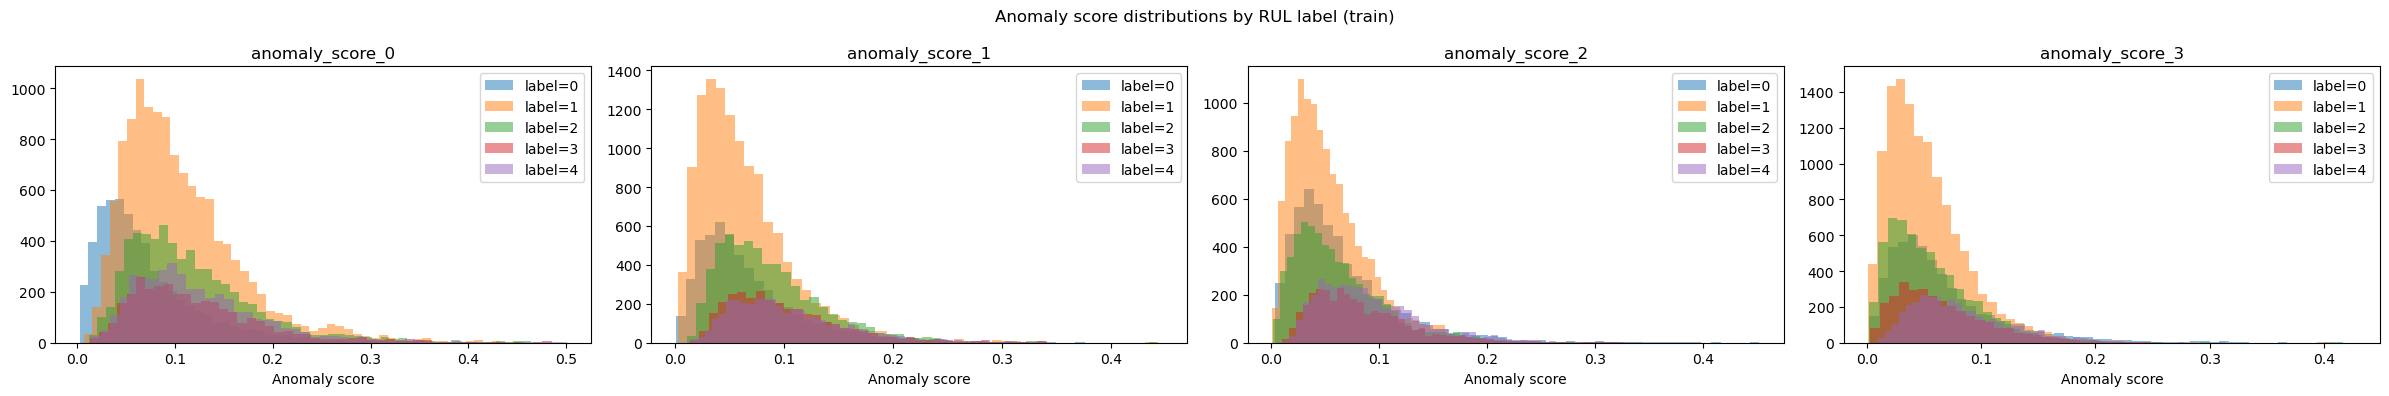

Spearman correlation (anomaly score vs label):
  anomaly_score_0: 0.2841
  anomaly_score_1: 0.3169
  anomaly_score_2: 0.2168
  anomaly_score_3: 0.1328


In [22]:
if score_cols and "label" in train_scored.columns:
    n = len(score_cols)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4), squeeze=False)
    for ax, sc in zip(axes[0], score_cols):
        for lbl, grp in train_scored.groupby("label"):
            ax.hist(grp[sc].dropna(), bins=50, alpha=0.5, label=f"label={lbl}")
        ax.set_title(sc); ax.set_xlabel("Anomaly score"); ax.legend()
    plt.suptitle("Anomaly score distributions by RUL label (train)")
    plt.tight_layout(); plt.show()

print("Spearman correlation (anomaly score vs label):")
for sc in score_cols:
    corr = train_scored[[sc, "label"]].dropna().corr(method="spearman").loc[sc, "label"]
    print(f"  {sc}: {corr:.4f}")

In [23]:
# ── XGBoost 数据准备：train_scored 已是欠采样结果，直接使用 ────────────────────
_drop_for_xgb  = {"vehicle_id", "time_step", "label"}
_xgb_feat_cols = [c for c in train_scored.columns if c not in _drop_for_xgb]

X_train_xgb_raw   = train_scored[_xgb_feat_cols].reset_index(drop=True)
y_train_xgb_raw   = train_scored["label"].astype(int).reset_index(drop=True)
groups_raw        = train_scored["vehicle_id"].reset_index(drop=True)
sample_weight_raw = compute_sample_weights(y_train_xgb_raw.to_numpy(), n_classes=N_CLASSES)

# 对 failure 类别（label > 0）额外加权
FAILURE_BOOST = 3.0
sample_weight_raw = np.where(y_train_xgb_raw > 0, sample_weight_raw * FAILURE_BOOST, sample_weight_raw)

# Validation
X_val_xgb_raw = val_scored.reindex(columns=_xgb_feat_cols).reset_index(drop=True)
y_val_xgb     = val_scored["label"].astype(int).reset_index(drop=True)

common_cols   = [c for c in X_train_xgb_raw.columns if c in X_val_xgb_raw.columns]
X_train_xgb   = X_train_xgb_raw[common_cols]
X_val_xgb     = X_val_xgb_raw[common_cols]
y_train_xgb   = y_train_xgb_raw
groups        = groups_raw
sample_weight = sample_weight_raw

print(f"Train label dist: {y_train_xgb.value_counts().sort_index().to_dict()}")
print(f"Val label dist  : {y_val_xgb.value_counts().sort_index().to_dict()}")
print(f"X_train_xgb: {X_train_xgb.shape}")
print(f"sample_weight: class-0={sample_weight[y_train_xgb==0].mean():.3f}  "
      f"class-1={sample_weight[y_train_xgb==1].mean():.3f}  "
      f"class-4={sample_weight[y_train_xgb==4].mean():.3f}")


Train label dist: {0: 5484, 1: 12503, 2: 6179, 3: 3200, 4: 3858}
Val label dist  : {0: 2944, 1: 12, 2: 9, 3: 21, 4: 41}
X_train_xgb: (31224, 117)
sample_weight: class-0=1.139  class-1=1.498  class-4=4.856


---
## 4. XGBoost Classification

Train an XGBoost 5-class classifier using temporally aggregated features + RFOD anomaly scores.
Hyperparameters are tuned via `RandomizedSearchCV` with `StratifiedGroupKFold`.
Class imbalance is handled via `compute_sample_weights`.

In [24]:

RANDOM_STATE = 42
N_SPLITS     = 3
N_ITER       = 10


def build_cv(y_train, groups, n_splits):
    try:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        list(cv.split(np.zeros(len(y_train)), y_train, groups))
        return cv
    except Exception:
        return GroupKFold(n_splits=n_splits)


def tune_pipeline_scania(pipeline, X_train, y_train, groups, n_splits, n_iter,
                          sample_weight=None):
    cv = build_cv(y_train, groups, n_splits)
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions={
            "model__n_estimators":     randint(150, 500),
            "model__max_depth":        randint(4, 10),
            "model__learning_rate":    uniform(0.03, 0.17),
            "model__subsample":        uniform(0.65, 0.35),
            "model__colsample_bytree": uniform(0.65, 0.35),
            "model__min_child_weight": randint(1, 8),
            "model__gamma":            uniform(0.0, 2.0),
            "model__reg_lambda":       uniform(0.5, 2.5),
            "model__reg_alpha":        uniform(0.0, 1.0),
        },
        n_iter=n_iter, scoring="f1_macro", cv=cv,
        refit=True, random_state=RANDOM_STATE, n_jobs=1, verbose=1,
    )
    fit_kw = {"groups": groups}
    if sample_weight is not None:
        fit_kw["model__sample_weight"] = sample_weight
    search.fit(X_train, y_train, **fit_kw)
    return search


def evaluate_predictions(y_true, y_pred, y_pred_proba=None, label=""):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    labels_all = list(range(N_CLASSES))
    result = {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0, labels=labels_all),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", zero_division=0, labels=labels_all),
        "total_cost":        total_cost(y_true, y_pred),
    }
    if y_pred_proba is not None:
        try:
            result["aucroc_ovr_macro"] = roc_auc_score(
                y_true, y_pred_proba, multi_class="ovr", average="macro", labels=labels_all
            )
        except Exception:
            result["aucroc_ovr_macro"] = float("nan")
    return result

print("evaluate_predictions defined.")

evaluate_predictions defined.


In [25]:
print("Building XGBoost pipeline (5-class) + RandomizedSearchCV...")
cat_cols_xgb = [c for c in X_train_xgb.columns if X_train_xgb[c].dtype == "object"]
num_cols_xgb = [c for c in X_train_xgb.columns if c not in cat_cols_xgb]
print(f"  cat features: {len(cat_cols_xgb)}  |  num features: {len(num_cols_xgb)}")

pipeline = build_model_pipeline(cat_cols_xgb, num_cols_xgb)
# GPU acceleration (change device='cpu' if no GPU available)
pipeline.named_steps["model"].set_params(tree_method="hist", device="cuda:2")

search = tune_pipeline_scania(
    pipeline=pipeline,
    X_train=X_train_xgb, y_train=y_train_xgb, groups=groups,
    n_splits=N_SPLITS, n_iter=N_ITER,
    sample_weight=sample_weight,
)

best_model   = search.best_estimator_
y_pred       = best_model.predict(X_val_xgb)
y_pred_proba = best_model.predict_proba(X_val_xgb)

m = evaluate_predictions(y_val_xgb, y_pred, y_pred_proba, label="argmax")
print(f"Best CV macro-F1 : {search.best_score_:.4f}")
print(f"Best params      : {search.best_params_}")
print()
print("── argmax validation metrics ──")
for k in ("accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "aucroc_ovr_macro", "total_cost"):
    v = m.get(k, "n/a")
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, float) else f"  {k:25s}: {v}")
print()
print(classification_report(
    y_val_xgb, y_pred, labels=list(range(N_CLASSES)),
    target_names=[f"class {i}" for i in range(N_CLASSES)], zero_division=0,
))


Building XGBoost pipeline (5-class) + RandomizedSearchCV...
  cat features: 8  |  num features: 109


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/ruiyao/anaconda3/envs/rapids-25.04/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [11:23:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:2, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best CV macro-F1 : 0.4514
Best params      : {'model__colsample_bytree': 0.9908144315945107, 'model__gamma': 0.46554268086060846, 'model__learning_rate': 0.04540309387057954, 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 204, 'model__reg_alpha': 0.9832308858067882, 'model__reg_lambda': 1.6669072331199497, 'model__subsample': 0.9509791423577122}

── argmax validation metrics ──
  accuracy                 : 0.6386
  balanced_accuracy        : 0.2661
  macro_f1                 : 0.1769
  weighted_f1              : 0.7606
  aucroc_ovr_macro         : 0.6572
  total_cost               : 60440

              precision    recall  f1-score   support

     class 0       0.98      0.65      0.78      2944
     class 1       0.00      0.08      0.01        12
     class 2       0.01      0.11      0.02         9
     class 3       0.02      0.05      0.02        21
     class 4       0.03      0.44      0.05        41

    accuracy                           0.64     

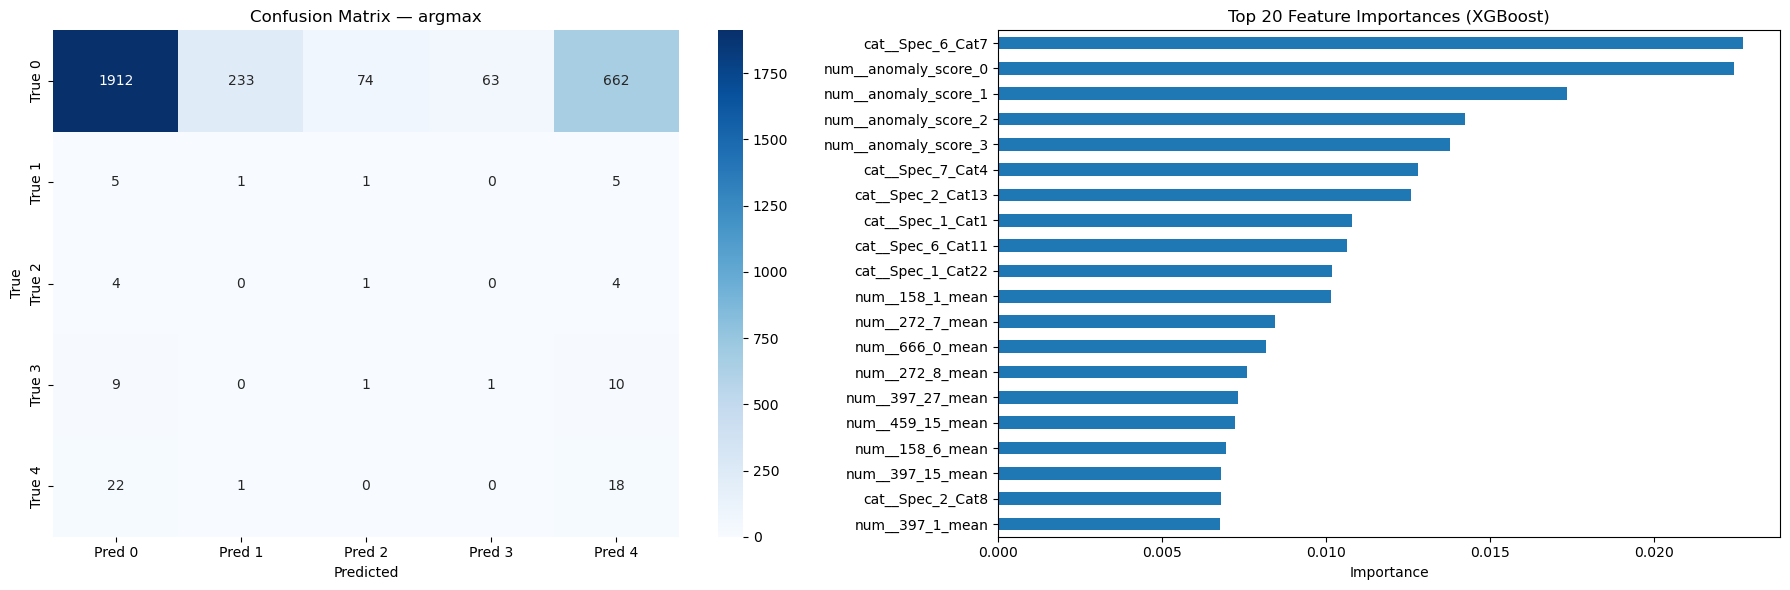

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Confusion matrix
cm_argmax = confusion_matrix(y_val_xgb, y_pred, labels=list(range(N_CLASSES)))
sns.heatmap(cm_argmax, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Pred {i}" for i in range(N_CLASSES)],
            yticklabels=[f"True {i}" for i in range(N_CLASSES)], ax=axes[0])
axes[0].set_title("Confusion Matrix — argmax")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Feature importance
xgb_step = best_model.named_steps["model"]
pre_step  = best_model.named_steps["preprocess"]
try:
    feat_names = pre_step.get_feature_names_out()
except Exception:
    feat_names = [f"f{i}" for i in range(len(xgb_step.feature_importances_))]
importances = pd.Series(xgb_step.feature_importances_, index=feat_names).nlargest(20)
importances.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Top 20 Feature Importances (XGBoost)")
axes[1].set_xlabel("Importance")

plt.tight_layout(); plt.show()

---
## 5. Cost Matrix RUL Prediction

Asymmetric cost matrix `COST` (5×5, rows=true label, cols=predicted label).
Underestimating urgency (predicting lower than true) incurs heavy penalties.

Four strategies compared:
1. **argmax** — direct `argmax(P(k|x))`
2. **threshold_moving** — grid search on 4 ordinal cut points `(τ₁..τ₄)` minimising total cost on validation set
3. **expected_cost_min** — `argmin(P @ COST, axis=1)`
4. **cost_matrix_perturb** — additive delta on off-diagonal, selected via OOF predictions (no val set leakage)

In [27]:
print("Cost matrix (COST):")
cost_df = pd.DataFrame(
    COST,
    index=[f"True {i}" for i in range(N_CLASSES)],
    columns=[f"Pred {i}" for i in range(N_CLASSES)],
)
print(cost_df.to_string())

Cost matrix (COST):
        Pred 0  Pred 1  Pred 2  Pred 3  Pred 4
True 0     0.0    20.0    30.0    40.0    50.0
True 1   200.0     0.0    20.0    30.0    40.0
True 2   300.0   200.0     0.0    20.0    30.0
True 3   400.0   300.0   200.0     0.0    20.0
True 4   500.0   400.0   300.0   200.0     0.0


In [28]:
# ── Strategy 1: argmax (already computed) ────────────────────────────────────
m_argmax = evaluate_predictions(y_val_xgb, y_pred, y_pred_proba)

# ── OOF predictions（复用于 Strategy 2 和 Strategy 4）─────────────────────────
print("Computing OOF predictions for threshold tuning + delta search (refits model per fold)...")
y_oof_proba = cross_val_predict(
    pipeline, X_train_xgb, y_train_xgb,
    cv=3, method="predict_proba",
    params={"model__sample_weight": sample_weight},
)

# ── Strategy 2: threshold_moving (ordinal risk score + 4 cut points) ─────────
# 使用训练集 OOF 概率搜索 theta，避免验证集样本太少（83条非零）导致 theta 退化
print("Tuning threshold vector on OOF predictions (training set)...")
theta_star, _ = tune_threshold_vector(y_oof_proba, y_train_xgb, COST, min_failure_recall=0.3)
y_pred_thr = predict_with_threshold_vector(y_pred_proba, theta_star)
m_thr = evaluate_predictions(y_val_xgb, y_pred_thr, y_pred_proba)
print(f"theta* = [{', '.join(f'{x:.4f}' for x in theta_star)}]")

# ── Strategy 3: expected cost minimisation (fixed matrix) ────────────────────
y_pred_ecm = np.argmin(y_pred_proba @ COST, axis=1)
m_ecm = evaluate_predictions(y_val_xgb, y_pred_ecm, y_pred_proba)

# ── Strategy 4: cost matrix perturbation (delta searched on OOF, no val leakage)
_offdiag_idx = [(r, c_) for r in range(N_CLASSES) for c_ in range(N_CLASSES) if r != c_]
_delta_range  = np.linspace(-5, 5, 41)

best_oof_cost, best_delta = None, 0.0
for _d in _delta_range:
    _cm_try = COST.astype(float).copy()
    for _r, _c in _offdiag_idx:
        _cm_try[_r, _c] = max(0.0, _cm_try[_r, _c] + _d)
    _yp_oof = np.argmin(y_oof_proba @ _cm_try, axis=1)
    _c_oof  = total_cost(y_train_xgb.values.astype(int), _yp_oof)
    if best_oof_cost is None or _c_oof < best_oof_cost:
        best_oof_cost = _c_oof
        best_delta    = float(_d)

best_cm_perturb = COST.astype(float).copy()
for _r, _c in _offdiag_idx:
    best_cm_perturb[_r, _c] = max(0.0, best_cm_perturb[_r, _c] + best_delta)
y_pred_perturb    = np.argmin(y_pred_proba @ best_cm_perturb, axis=1)
best_cost_perturb = total_cost(np.asarray(y_val_xgb, int), y_pred_perturb)
m_perturb = evaluate_predictions(y_val_xgb, y_pred_perturb, y_pred_proba)

print(f"Best delta={best_delta:+.1f}  OOF cost={best_oof_cost}  val cost={best_cost_perturb}")
print("Perturbed cost matrix:")
print(pd.DataFrame(best_cm_perturb.round(1),
    index=[f"True {i}" for i in range(N_CLASSES)],
    columns=[f"Pred {i}" for i in range(N_CLASSES)]).to_string())

# ── Strategy comparison summary ───────────────────────────────────────────────
summary_cols = ["accuracy", "balanced_accuracy", "macro_f1", "total_cost"]
summary = pd.DataFrame({
    "argmax":              {k: m_argmax.get(k)  for k in summary_cols},
    "threshold_moving":    {k: m_thr.get(k)     for k in summary_cols},
    "expected_cost_min":   {k: m_ecm.get(k)     for k in summary_cols},
    "cost_matrix_perturb": {k: m_perturb.get(k) for k in summary_cols},
}).T
print("── Strategy comparison ──")
print(summary.round(4).to_string())

Computing OOF predictions for threshold tuning + delta search (refits model per fold)...


Tuning threshold vector on OOF predictions (training set)...


theta* = [0.0000, 0.0000, 0.0000, 0.0000]
Best delta=-5.0  OOF cost=1406700  val cost=123750
Perturbed cost matrix:
        Pred 0  Pred 1  Pred 2  Pred 3  Pred 4
True 0     0.0    15.0    25.0    35.0    45.0
True 1   195.0     0.0    15.0    25.0    35.0
True 2   295.0   195.0     0.0    15.0    25.0
True 3   395.0   295.0   195.0     0.0    15.0
True 4   495.0   395.0   295.0   195.0     0.0
── Strategy comparison ──
                     accuracy  balanced_accuracy  macro_f1  total_cost
argmax                 0.6386             0.2661    0.1769     60440.0
threshold_moving       0.0135             0.2000    0.0053    148370.0
expected_cost_min      0.1397             0.2401    0.0568    121570.0
cost_matrix_perturb    0.1216             0.2363    0.0507    123750.0


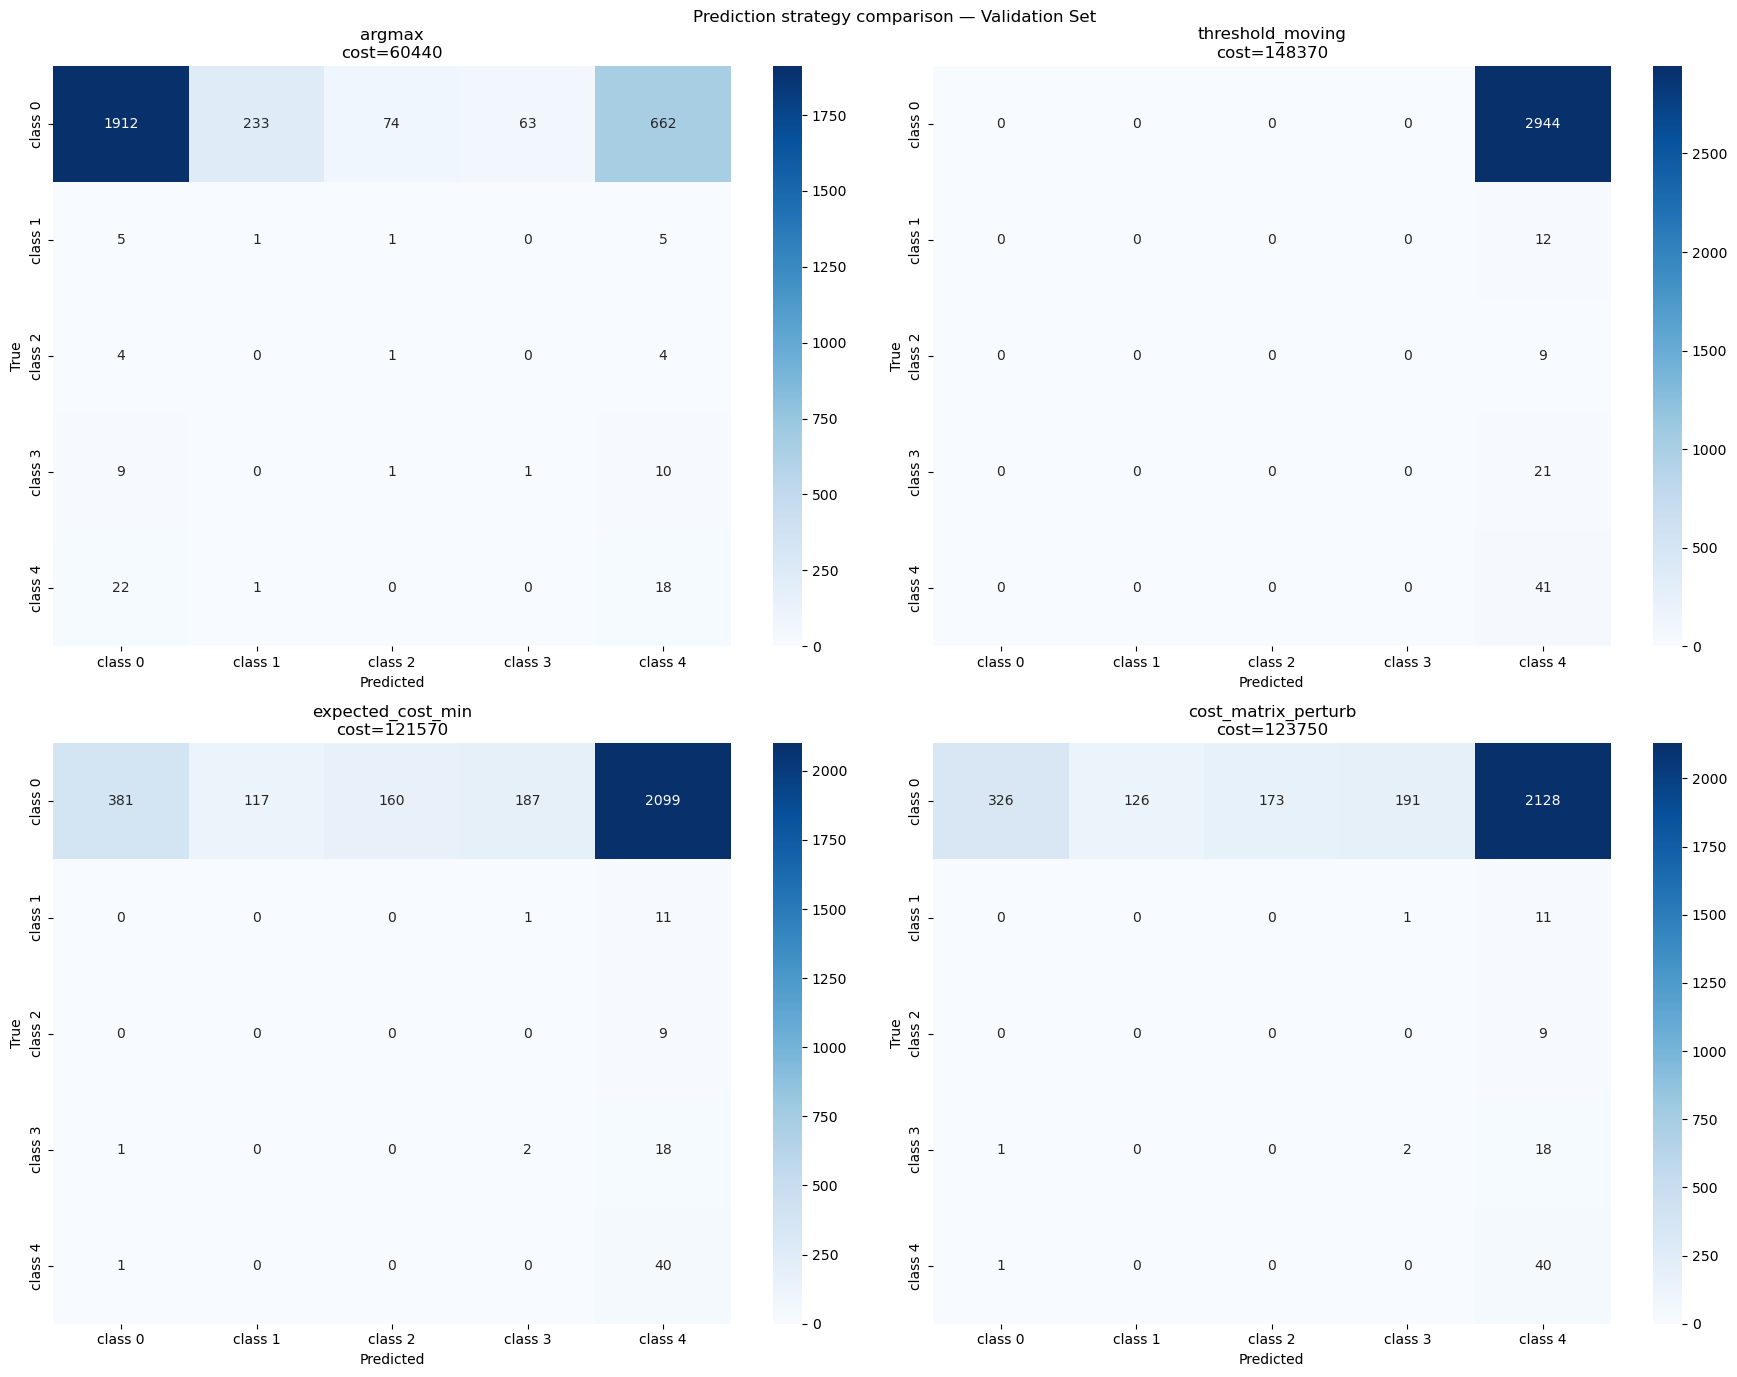

In [29]:
strategies = [
    ("argmax",              y_pred),
    ("threshold_moving",    y_pred_thr),
    ("expected_cost_min",   y_pred_ecm),
    ("cost_matrix_perturb", y_pred_perturb),
]
tick_labels = [f"class {i}" for i in range(N_CLASSES)]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (name, preds) in zip(axes.flat, strategies):
    cm_plot = confusion_matrix(y_val_xgb, preds, labels=list(range(N_CLASSES)))
    sns.heatmap(cm_plot, annot=True, fmt="d", cmap="Blues",
                xticklabels=tick_labels, yticklabels=tick_labels, ax=ax)
    ax.set_title(f"{name}\ncost={total_cost(y_val_xgb, preds)}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Prediction strategy comparison — Validation Set")
plt.tight_layout(); plt.show()

In [30]:
y_true_arr = np.asarray(y_val_xgb, dtype=int)
breakdown = pd.DataFrame({
    "true_label":         y_true_arr,
    "cost_argmax":        COST[y_true_arr, np.asarray(y_pred,         int)],
    "cost_threshold":     COST[y_true_arr, np.asarray(y_pred_thr,     int)],
    "cost_expected_cost": COST[y_true_arr, np.asarray(y_pred_ecm,     int)],
    "cost_cm_perturb":    COST[y_true_arr, np.asarray(y_pred_perturb, int)],
})
print("Mean cost per true label class:")
print(breakdown.groupby("true_label")[
    ["cost_argmax", "cost_threshold", "cost_expected_cost", "cost_cm_perturb"]
].mean().round(3).to_string())

Mean cost per true label class:
            cost_argmax  cost_threshold  cost_expected_cost  cost_cm_perturb
true_label                                                                  
0                14.436            50.0              40.615           41.355
1               101.667            40.0              39.167           39.167
2               146.667            30.0              30.000           30.000
3               190.476            20.0              36.190           36.190
4               278.049             0.0              12.195           12.195


── F1 per class ──
class                class-0  class-1  class-2  class-3  class-4
strategy                                                        
argmax                 0.781    0.008    0.023    0.024    0.049
cost_matrix_perturb    0.199    0.000    0.000    0.019    0.036
expected_cost_min      0.229    0.000    0.000    0.019    0.036
threshold_moving       0.000    0.000    0.000    0.000    0.027

── Precision per class ──
class                class-0  class-1  class-2  class-3  class-4
strategy                                                        
argmax                 0.980    0.004    0.013    0.016    0.026
cost_matrix_perturb    0.994    0.000    0.000    0.010    0.018
expected_cost_min      0.995    0.000    0.000    0.011    0.018
threshold_moving       0.000    0.000    0.000    0.000    0.014

── Recall per class ──
class                class-0  class-1  class-2  class-3  class-4
strategy                                                        
argmax              

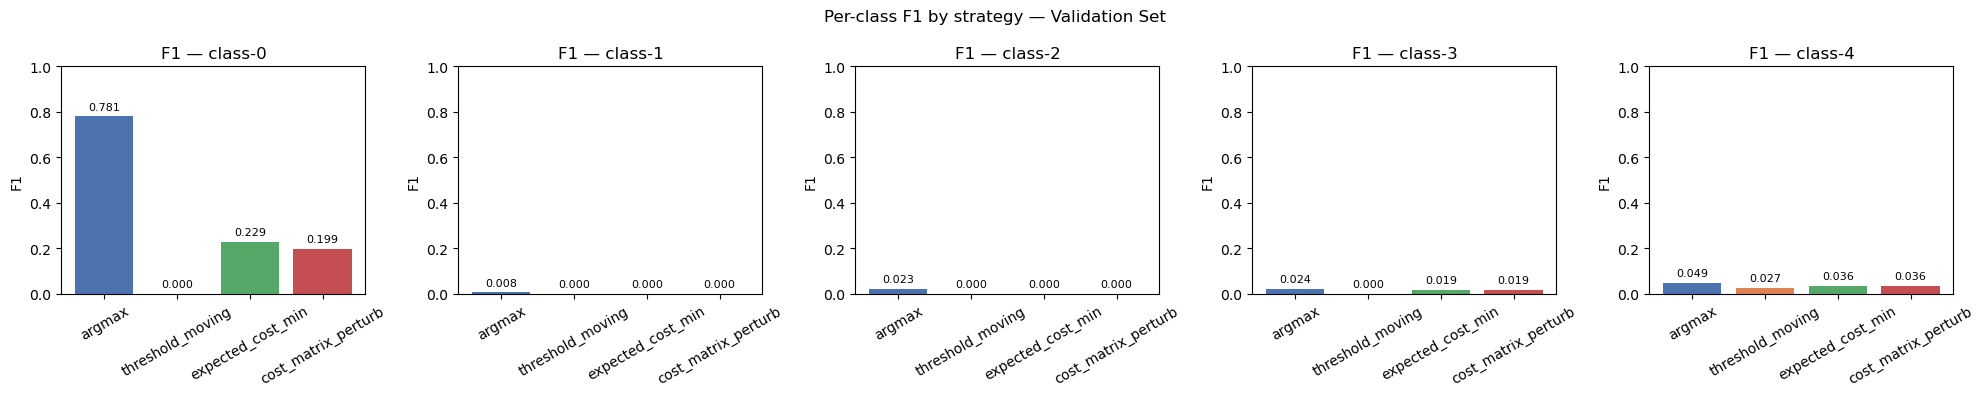

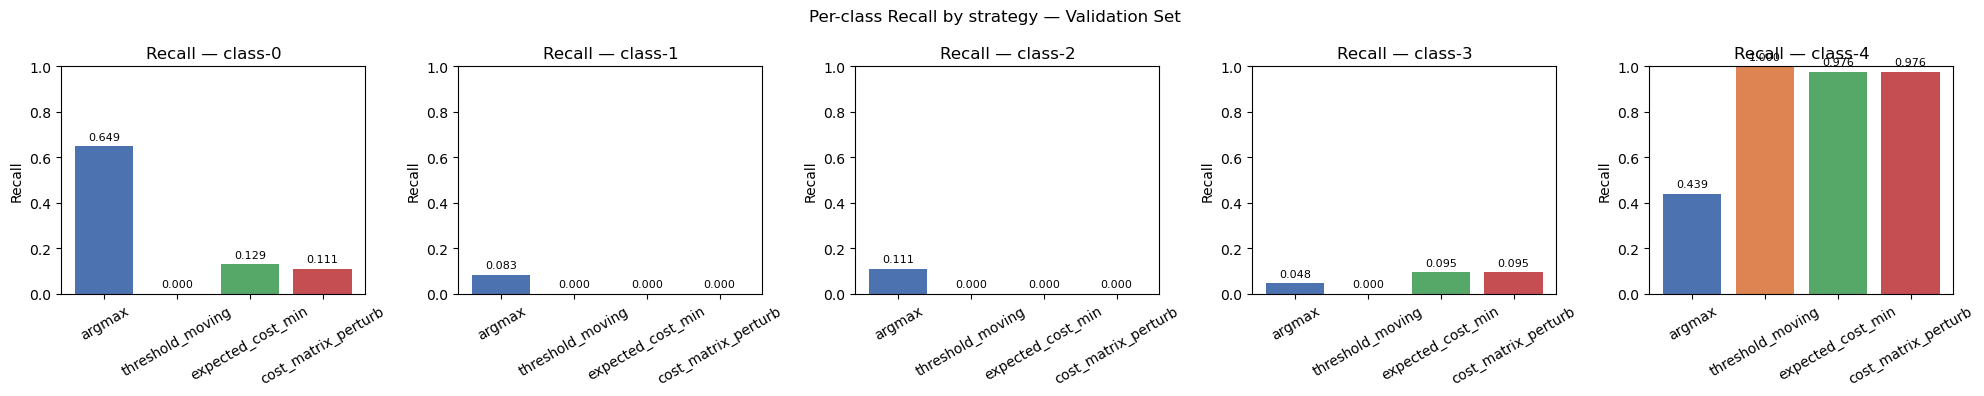

In [31]:
_strategies_preds = [
    ("argmax",              y_pred),
    ("threshold_moving",    y_pred_thr),
    ("expected_cost_min",   y_pred_ecm),
    ("cost_matrix_perturb", y_pred_perturb),
]
_class_names = [f"class-{i}" for i in range(N_CLASSES)]
_y_true      = np.asarray(y_val_xgb, dtype=int)

rows = []
for strat_name, preds in _strategies_preds:
    preds = np.asarray(preds, dtype=int)
    p, r, f, sup = precision_recall_fscore_support(
        _y_true, preds, labels=list(range(N_CLASSES)), zero_division=0
    )
    for i, cls in enumerate(_class_names):
        rows.append({"strategy": strat_name, "class": cls,
                     "precision": p[i], "recall": r[i], "f1": f[i], "support": int(sup[i])})

per_class_df = pd.DataFrame(rows)
pivot_f1   = per_class_df.pivot(index="strategy", columns="class", values="f1").round(3)
pivot_prec = per_class_df.pivot(index="strategy", columns="class", values="precision").round(3)
pivot_rec  = per_class_df.pivot(index="strategy", columns="class", values="recall").round(3)

print("── F1 per class ──");     print(pivot_f1.to_string())
print("\n── Precision per class ──"); print(pivot_prec.to_string())
print("\n── Recall per class ──");    print(pivot_rec.to_string())

_colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]

fig, axes = plt.subplots(1, N_CLASSES, figsize=(4*N_CLASSES, 4), sharey=False)
for ax, cls in zip(axes, _class_names):
    sub = per_class_df[per_class_df["class"] == cls]
    bars = ax.bar(sub["strategy"], sub["f1"], color=_colors)
    ax.set_title(f"F1 — {cls}"); ax.set_ylim(0, 1); ax.set_ylabel("F1")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, sub["f1"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Per-class F1 by strategy — Validation Set")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_CLASSES, figsize=(4*N_CLASSES, 4), sharey=False)
for ax, cls in zip(axes, _class_names):
    sub = per_class_df[per_class_df["class"] == cls]
    bars = ax.bar(sub["strategy"], sub["recall"], color=_colors)
    ax.set_title(f"Recall — {cls}"); ax.set_ylim(0, 1); ax.set_ylabel("Recall")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, sub["recall"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Per-class Recall by strategy — Validation Set")
plt.tight_layout(); plt.show()

In [32]:
# ── Test Set Prediction and Submission ─────────────────────────────────────
_test_xgb_cols = [c for c in _xgb_feat_cols if c in test_scored.columns]
X_test_xgb = test_scored.reindex(columns=common_cols).reset_index(drop=True)

y_test_proba = best_model.predict_proba(X_test_xgb)

# ── 选择预测策略（取消注释其中一行）────────────────────────────────────────
# Strategy 1: argmax — 直接取概率最大类别
# y_test_pred = best_model.predict(X_test_xgb)

# Strategy 2: threshold_moving — ordinal risk score + 4 切点，在验证集上搜索
y_test_pred = predict_with_threshold_vector(y_test_proba, theta_star)

# Strategy 3: expected_cost_min — argmin(P @ COST)，无验证集泄漏
# y_test_pred = np.argmin(y_test_proba @ COST, axis=1)

# Strategy 4: cost_matrix_perturb — 使用 OOF 搜索到的扰动矩阵
# y_test_pred = np.argmin(y_test_proba @ best_cm_perturb, axis=1)

write_scania_submission_csv(
    out_path=PROJECT_DIR / "scania_submission.csv",
    vehicle_ids=test_scored["vehicle_id"].to_numpy(),
    labels=y_test_pred,
)

print("Test label distribution:")
for lbl, cnt in pd.Series(y_test_pred).value_counts().sort_index().items():
    print(f"  class {lbl}: {cnt:>6,}  ({100*cnt/len(y_test_pred):.1f}%)")



Submission CSV (id, label):
  Written: scania_submission.csv
  Rows: 7,064
Test label distribution:
  class 4:  7,064  (100.0%)
